In [2]:
!pip install pandas


Access is denied.


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the CSV file into a DataFrame
df = pd.read_csv('Superstore.csv', encoding='latin1')

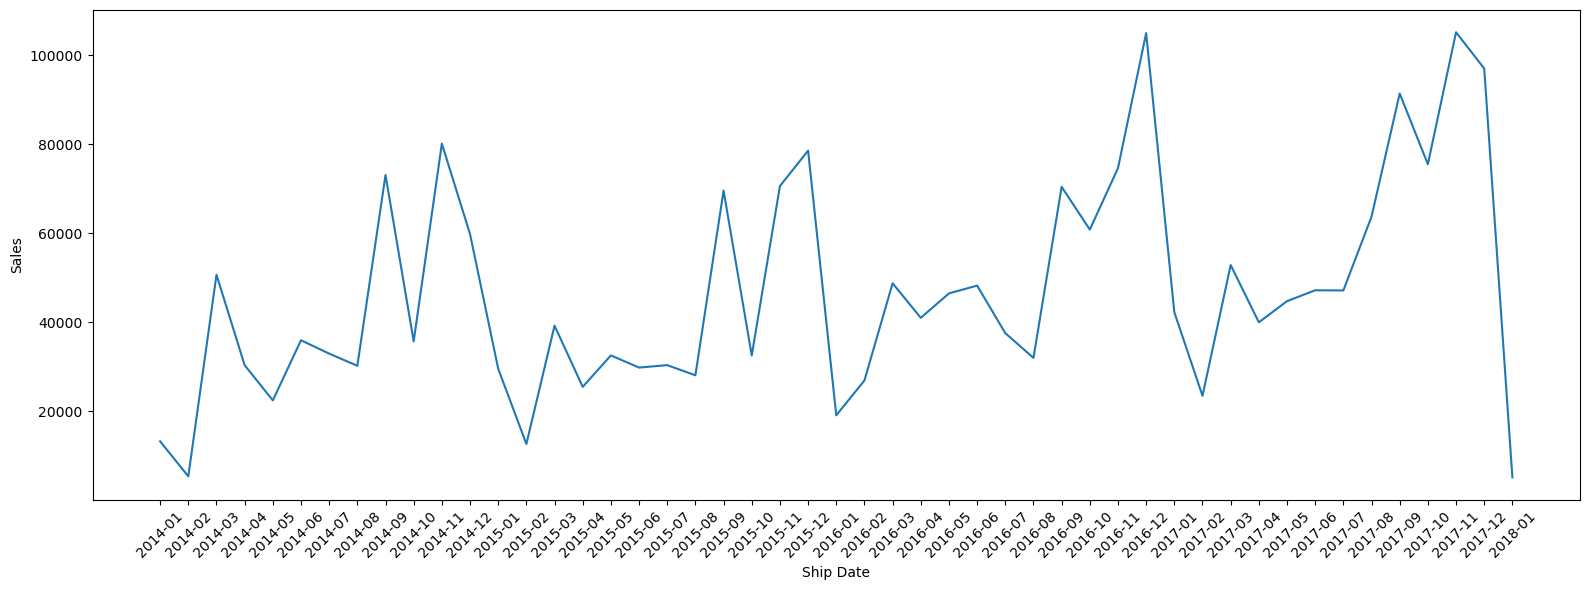

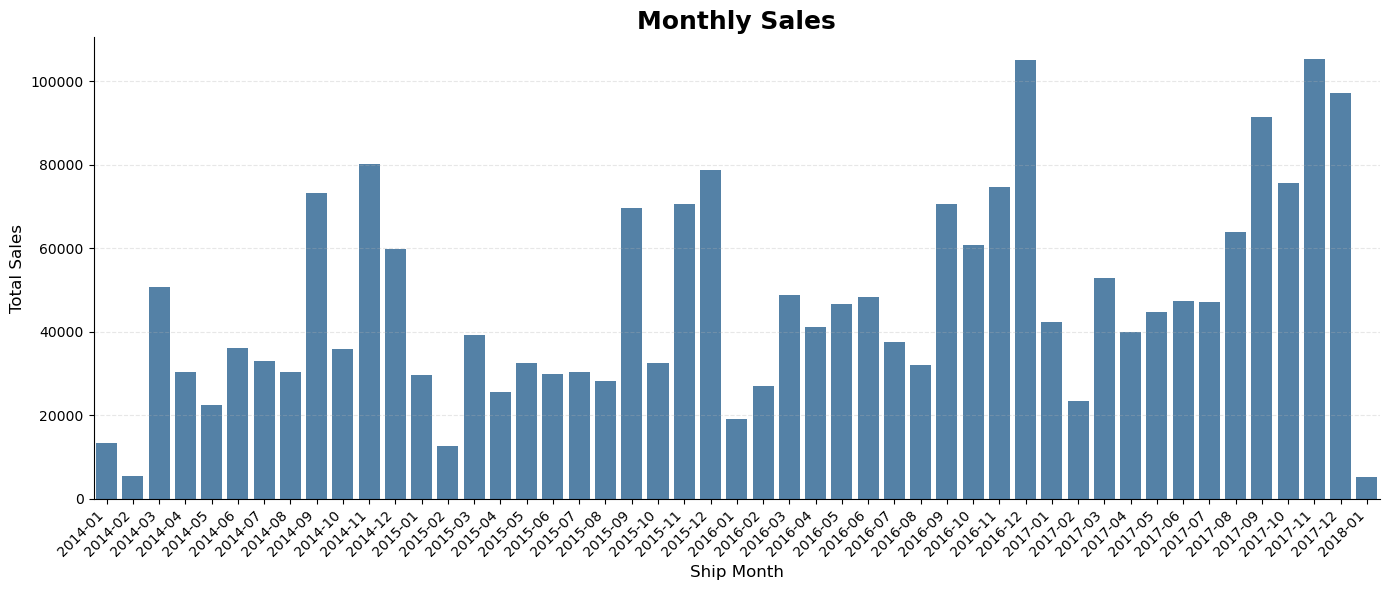

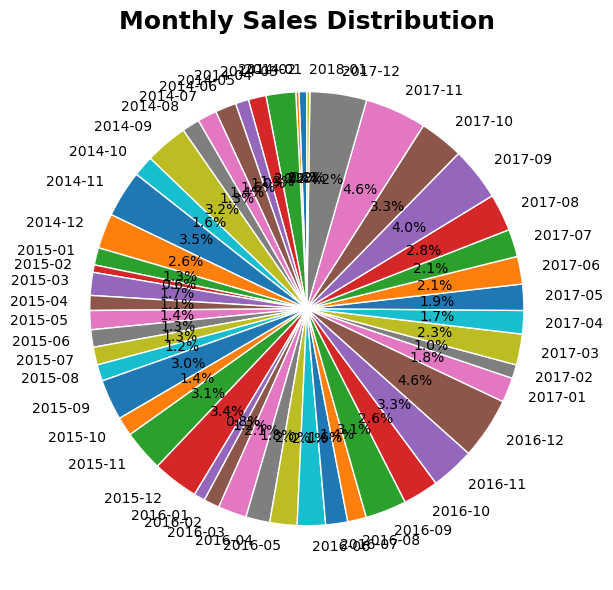

In [43]:
# 1. You will be given the total monthly sales already summarized by month. Plot this as a
# bar chart, a line chart, and a pie chart: "Which chart shows the trend best, and which
# one hides it? Why?"

df['Ship Date'] = pd.to_datetime(df['Ship Date'])

salesByMonth = (df.groupby(df['Ship Date'].dt.to_period('M'))['Sales'].sum().reset_index())

salesByMonth['Ship Date'] = salesByMonth['Ship Date'].astype(str)



plt.figure(figsize=(16, 6))

sns.lineplot(data=salesByMonth, x='Ship Date', y='Sales')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


plt.figure(figsize=(14, 6))

sns.barplot(
    data=salesByMonth,
    x='Ship Date',
    y='Sales',
    color='steelblue'
)

plt.title('Monthly Sales', fontsize=18, fontweight='bold')
plt.xlabel('Ship Month', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.3)

sns.despine()
plt.tight_layout()
plt.show()



plt.figure(figsize=(10, 6))


plt.pie(
    salesByMonth['Sales'],
    labels=salesByMonth['Ship Date'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1}
)

plt.title('Monthly Sales Distribution', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()


# Best representation is line 





### 2. For each statement below, pick the chart type, build it, and justify in 1-2 sentences
### why it fits and why the "weak choice" would mislead or underperform:

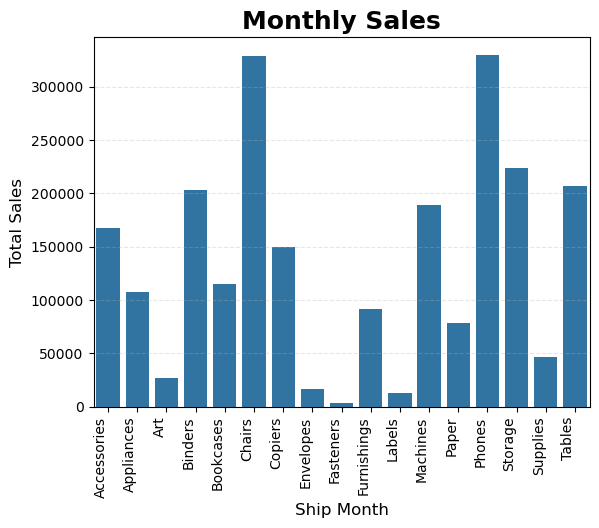

In [52]:
# "Compare total sales across the top 5 sub-categories." (You will be given the top 5
# sub-categories already totaled.)

salesByCategory = df.groupby("Sub-Category")['Sales'].sum('Sales').reset_index()
sns.barplot(data=salesByCategory, x='Sub-Category', y='Sales')
plt.title('Monthly Sales', fontsize=18, fontweight='bold')
plt.xlabel('Ship Month', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)

plt.xticks(rotation=90, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.3)


# Barplot is best. Pie chart will be "weaker" since there will be many categories, it will make it harder to comprehend and differenciate between
# similar sales

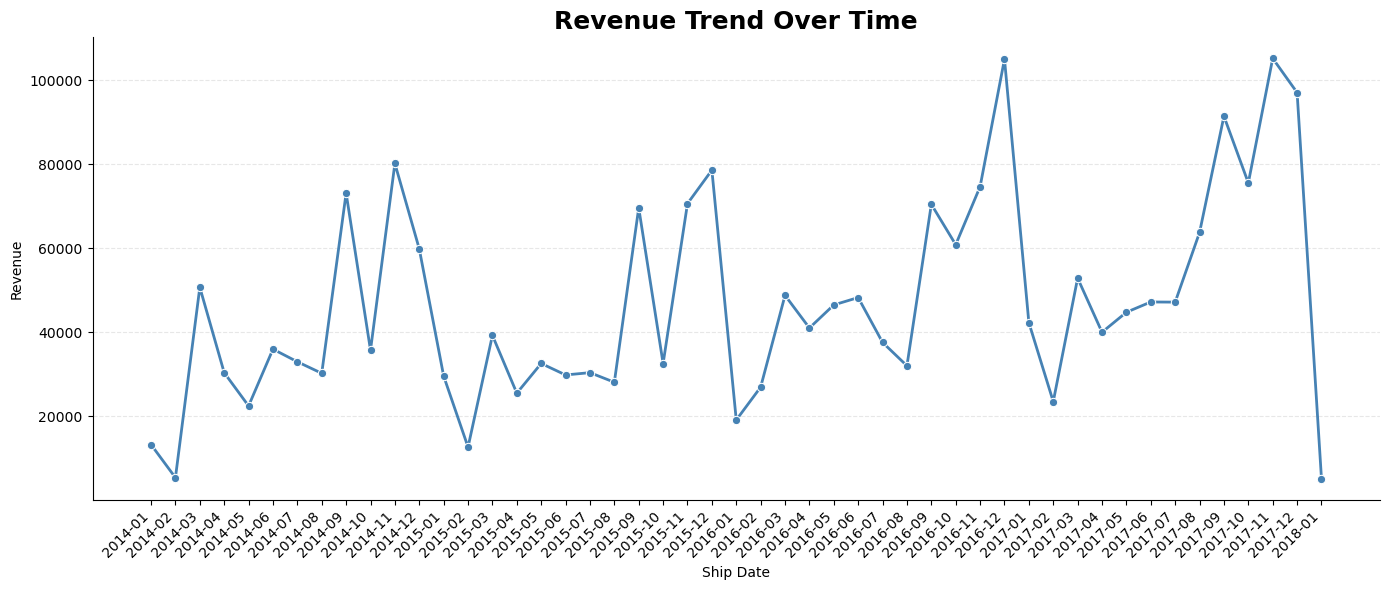

In [53]:
# "Show the revenue trend over time." (Reuse the monthly sales data from Task 1.)
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=salesByMonth,
    x='Ship Date',
    y='Sales',
    marker='o',
    color='steelblue',
    linewidth=2
)

plt.title('Revenue Trend Over Time',
          fontsize=18, fontweight='bold')
plt.xlabel('Ship Date')
plt.ylabel('Revenue')

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.3)

sns.despine()
plt.tight_layout()
plt.show()
#Line chart best since there are many values of x so it would be hard to visualize with for example, a bar chart

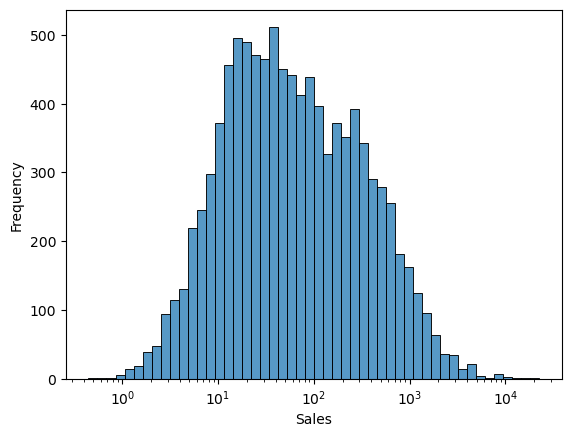

In [63]:
# "Show the distribution of order-line sales values." (Use the raw sales column
# directly — no summarizing needed.)
sns.histplot(data=df, x='Sales', bins=50, log_scale=True)
plt.ylabel("Frequency")
plt.show()

# Histogram best since it is the graph we use to visualize distribbutions

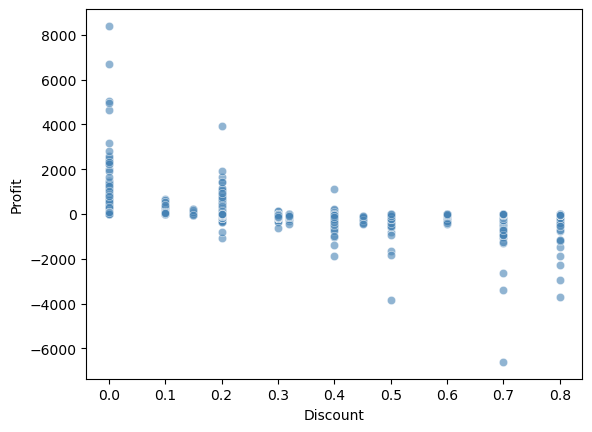

In [65]:
# "Show the relationship between discount level and profit." (Use the raw discount
# and profit columns directly — no summarizing needed.)

sns.scatterplot(data=df,x='Discount',y='Profit',color='steelblue',alpha=0.6)
plt.show()

#Scatterplot best since we use it for differentiation

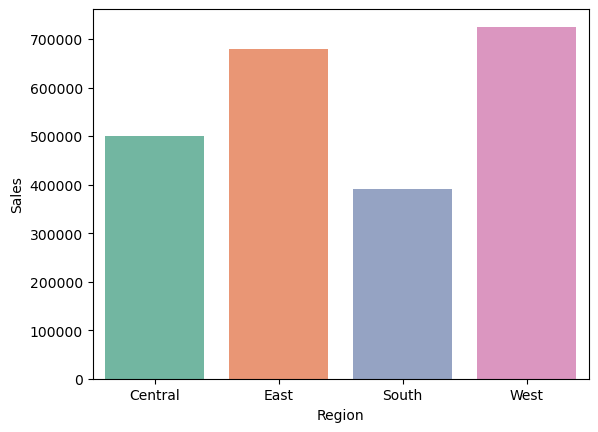

In [79]:
# 3. You will be given: total sales by region, sales by region-and-category, and total profit
# by month.
# (a) Recolor the region sales chart with a proper categorical palette.
# (b) Recolor the region-by-category data as a heatmap using a sequential palette.
# (c) Build a diverging-color chart of monthly profit, since it crosses zero.

salesByRegion = df.groupby("Region")['Sales'].sum().reset_index()
salesByRegion

sns.barplot(data=salesByRegion, x='Region', y='Sales', palette='Set2',hue='Region',legend=False)
plt.show()



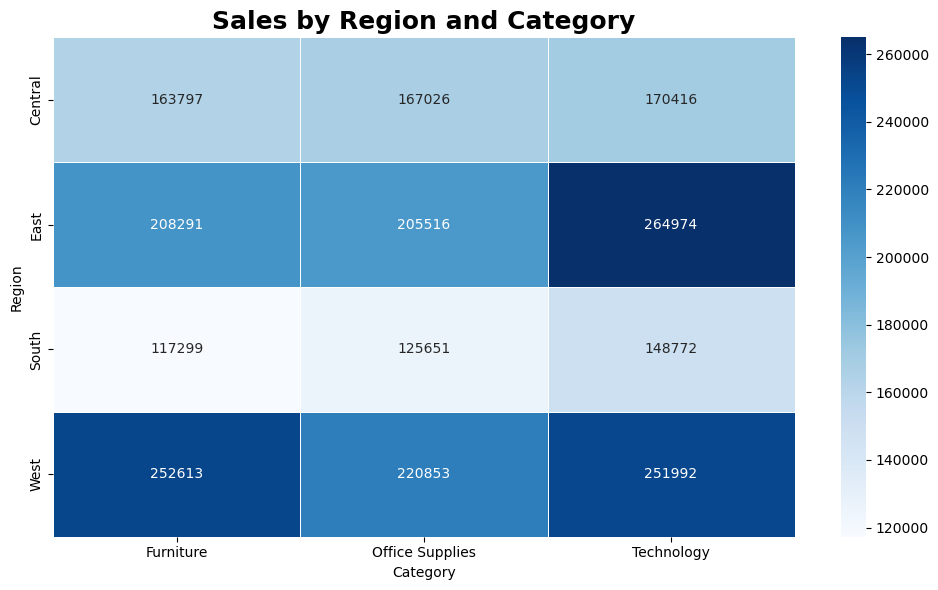

In [82]:
# (b) Recolor the region-by-category data as a heatmap using a sequential palette.
regionCategory = df.pivot_table(index='Region',columns='Category',values='Sales',aggfunc='sum')

plt.figure(figsize=(10, 6))

sns.heatmap(regionCategory,cmap='Blues',annot=True,fmt='.0f',linewidths=0.5)

plt.title('Sales by Region and Category', fontsize=18, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Region')

plt.tight_layout()
plt.show()


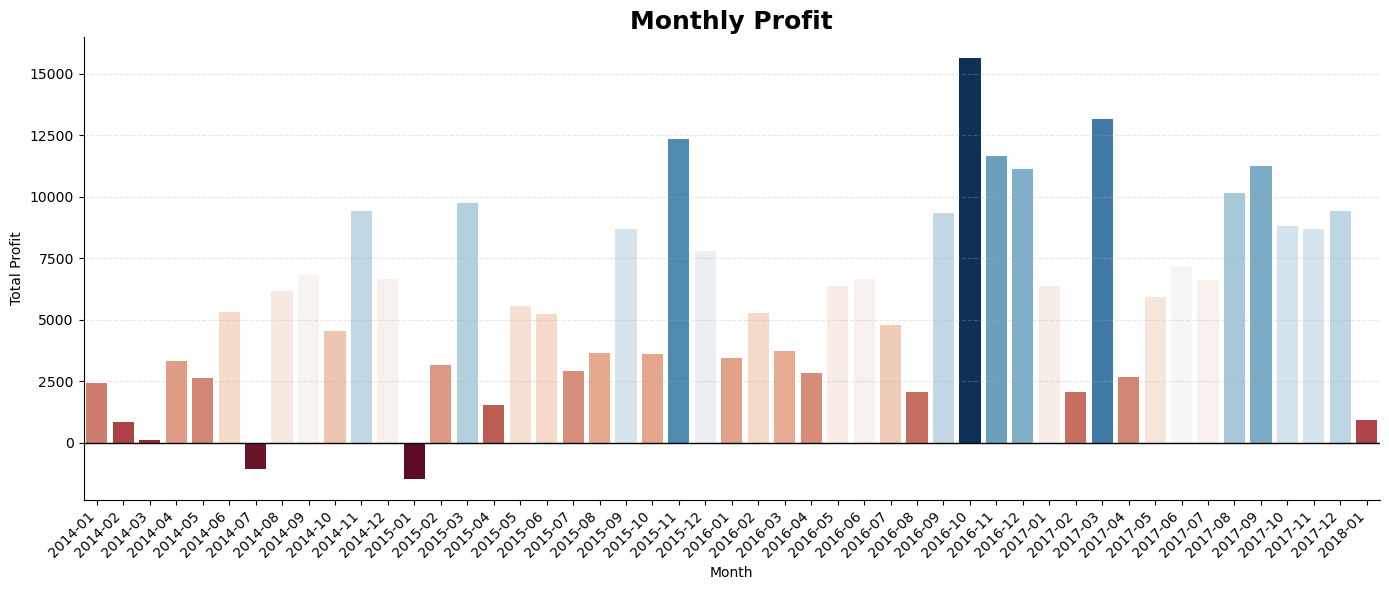

In [84]:
# (c) Build a diverging-color chart of monthly profit, since it crosses zero.

profitByMonth = (
    df.groupby(df['Ship Date'].dt.to_period('M'))['Profit']
      .sum()
      .reset_index()
)

profitByMonth['Ship Date'] = profitByMonth['Ship Date'].astype(str)

plt.figure(figsize=(14, 6))

sns.barplot(
    data=profitByMonth,
    x='Ship Date',
    y='Profit',
    hue='Profit',
    palette='RdBu',
    legend=False
)

plt.axhline(0, color='black', linewidth=1)

plt.title('Monthly Profit', fontsize=18, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Profit')

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.3)

sns.despine()
plt.tight_layout()
plt.show()



In [88]:
# 4

def relative_luminance(rgb):
    rgb = [c / 255 for c in rgb]

    rgb = [
        c / 12.92 if c <= 0.03928
        else ((c + 0.055) / 1.055) ** 2.4
        for c in rgb
    ]

    return (
        0.2126 * rgb[0] +
        0.7152 * rgb[1] +
        0.0722 * rgb[2]
    )


def contrast_ratio(color1, color2):
    L1 = relative_luminance(color1)
    L2 = relative_luminance(color2)

    lighter = max(L1, L2)
    darker = min(L1, L2)

    return (lighter + 0.05) / (darker + 0.05)


black = (0, 0, 0)
white = (255, 255, 255)

ratio = contrast_ratio(black, white)

print(f"Contrast ratio: {ratio:.2f}:1")

if ratio >= 4.5:
    print("PASS - Meets WCAG AA")
else:
    print("FAIL - Does not meet WCAG AA")

Contrast ratio: 21.00:1
PASS - Meets WCAG AA


In [89]:
set2_colors = sns.color_palette('Set2', 4)
blues_colors = sns.color_palette('Blues', 5)
rdbu_colors = sns.color_palette('RdBu', 5)

def convert_to_255(colors):
    return [
        tuple(round(value * 255) for value in color)
        for color in colors
    ]


set2_rgb = convert_to_255(set2_colors)
blues_rgb = convert_to_255(blues_colors)
rdbu_rgb = convert_to_255(rdbu_colors)

def test_palette(palette_name, colors):
    print(f"\n{palette_name}")
    print("=" * 50)

    for i in range(len(colors)):
        for j in range(i + 1, len(colors)):

            ratio = contrast_ratio(colors[i], colors[j])

            if ratio >= 4.5:
                result = "PASS"
            else:
                result = "FAIL"

            print(
                f"Color {i+1} vs Color {j+1}: "
                f"{ratio:.2f}:1 -> {result}"
            )

test_palette("Task 3(a) - Set2", set2_rgb)
test_palette("Task 3(b) - Blues", blues_rgb)
test_palette("Task 3(c) - RdBu", rdbu_rgb)



Task 3(a) - Set2
Color 1 vs Color 2: 1.08:1 -> FAIL
Color 1 vs Color 3: 1.22:1 -> FAIL
Color 1 vs Color 4: 1.11:1 -> FAIL
Color 2 vs Color 3: 1.14:1 -> FAIL
Color 2 vs Color 4: 1.03:1 -> FAIL
Color 3 vs Color 4: 1.10:1 -> FAIL

Task 3(b) - Blues
Color 1 vs Color 2: 1.28:1 -> FAIL
Color 1 vs Color 3: 1.91:1 -> FAIL
Color 1 vs Color 4: 3.06:1 -> FAIL
Color 1 vs Color 5: 5.40:1 -> PASS
Color 2 vs Color 3: 1.49:1 -> FAIL
Color 2 vs Color 4: 2.39:1 -> FAIL
Color 2 vs Color 5: 4.22:1 -> FAIL
Color 3 vs Color 4: 1.60:1 -> FAIL
Color 3 vs Color 5: 2.83:1 -> FAIL
Color 4 vs Color 5: 1.76:1 -> FAIL

Task 3(c) - RdBu
Color 1 vs Color 2: 2.73:1 -> FAIL
Color 1 vs Color 3: 4.39:1 -> FAIL
Color 1 vs Color 4: 2.87:1 -> FAIL
Color 1 vs Color 5: 1.15:1 -> FAIL
Color 2 vs Color 3: 1.61:1 -> FAIL
Color 2 vs Color 4: 1.05:1 -> FAIL
Color 2 vs Color 5: 2.38:1 -> FAIL
Color 3 vs Color 4: 1.53:1 -> FAIL
Color 3 vs Color 5: 3.82:1 -> FAIL
Color 4 vs Color 5: 2.49:1 -> FAIL


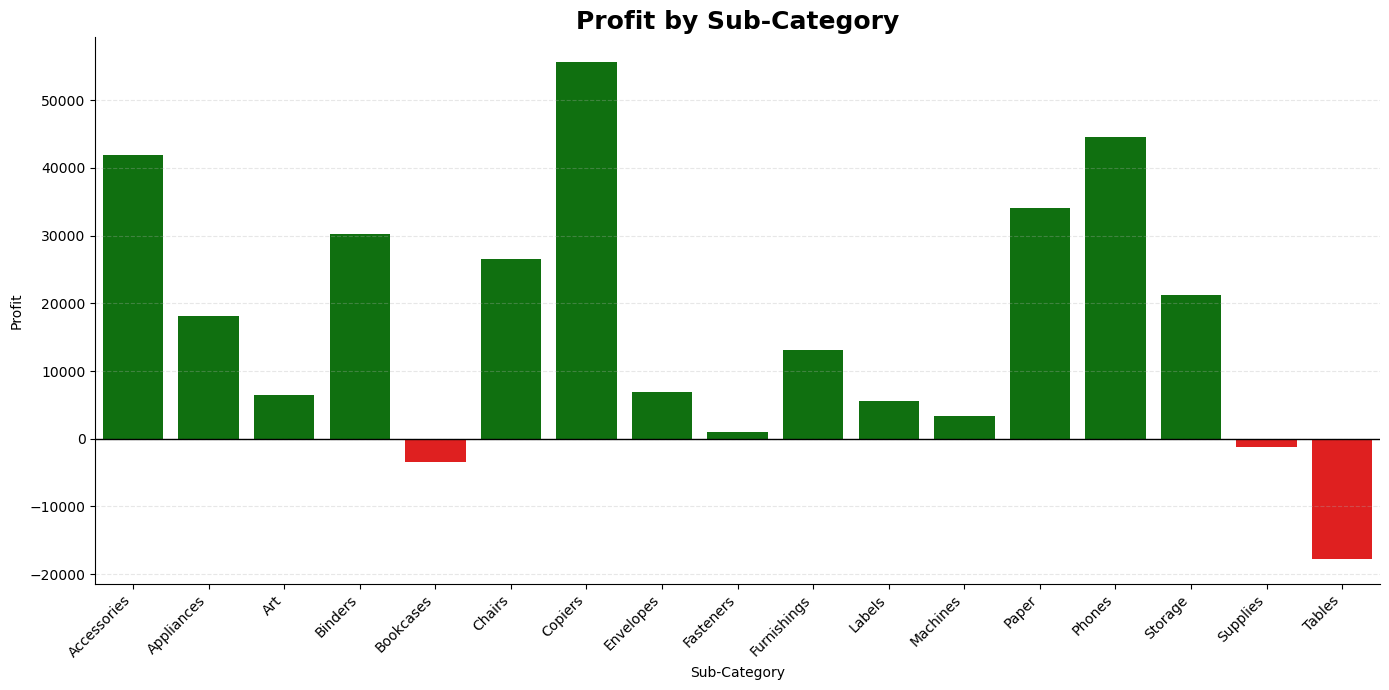

In [91]:
# (b) You will be given profit by sub-category. Build a chart that encodes loss vs. gain
# using red and green only. Run it through a provided colorblind-simulation snippet and
# screenshot before/after. Then fix the chart using hatching or marker shape so the
# distinction survives the simulation, and write one line of alt text describing the chart.
profitBySubCategory = df.groupby("Sub-Category")['Profit'].sum().reset_index()

plt.figure(figsize=(14, 7))

colors = [
    'green' if profit >= 0 else 'red'
    for profit in profitBySubCategory['Profit']
]

sns.barplot(
    data=profitBySubCategory,
    x='Sub-Category',
    y='Profit',
    hue='Sub-Category',
    palette=colors,
    legend=False
)

plt.axhline(0, color='black', linewidth=1)

plt.title('Profit by Sub-Category', fontsize=18, fontweight='bold')
plt.xlabel('Sub-Category')
plt.ylabel('Profit')

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.3)

sns.despine()
plt.tight_layout()
plt.show()


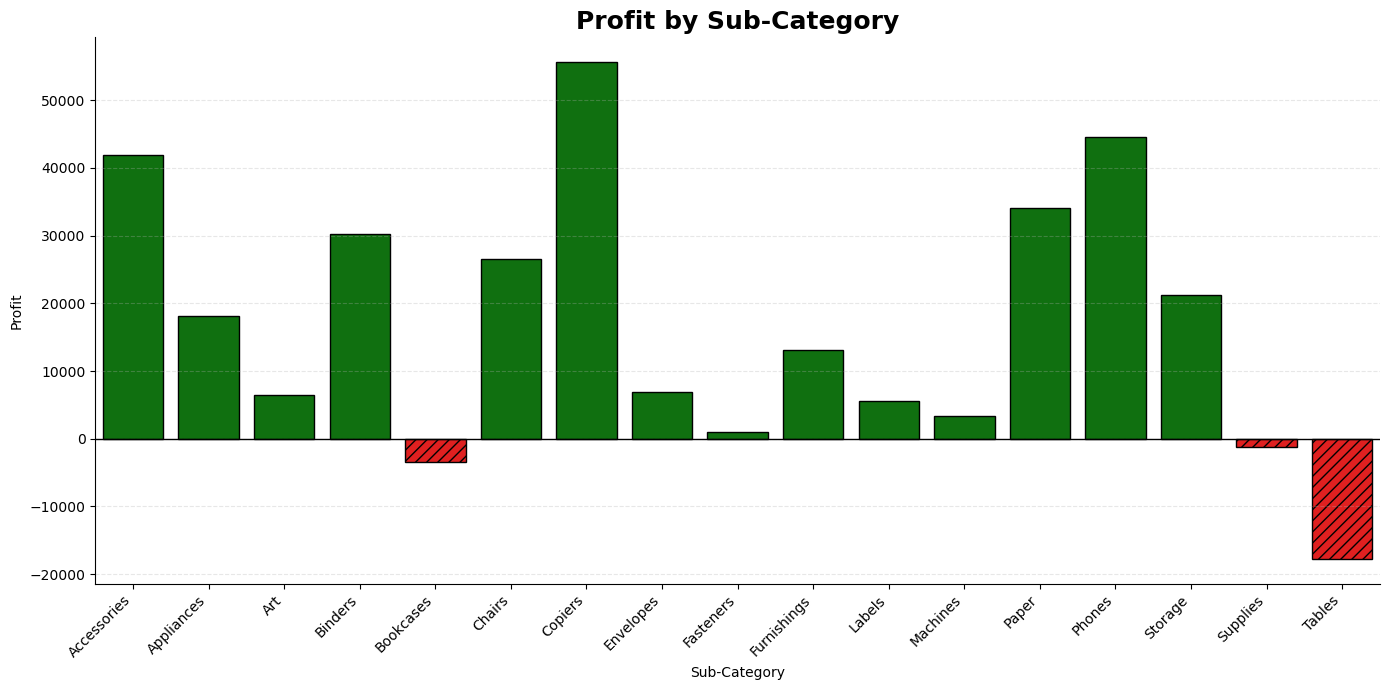

In [92]:
plt.figure(figsize=(14, 7))

colors = []
hatches = []

for profit in profitBySubCategory['Profit']:
    if profit >= 0:
        colors.append('green')
        hatches.append('')
    else:
        colors.append('red')
        hatches.append('///')

ax = sns.barplot(
    data=profitBySubCategory,
    x='Sub-Category',
    y='Profit',
    hue='Sub-Category',
    palette=colors,
    legend=False
)

for bar, hatch in zip(ax.patches, hatches):
    bar.set_hatch(hatch)
    bar.set_edgecolor('black')
    bar.set_linewidth(1)

plt.axhline(0, color='black', linewidth=1)

plt.title('Profit by Sub-Category', fontsize=18, fontweight='bold')
plt.xlabel('Sub-Category')
plt.ylabel('Profit')

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.3)

sns.despine()
plt.tight_layout()
plt.show()


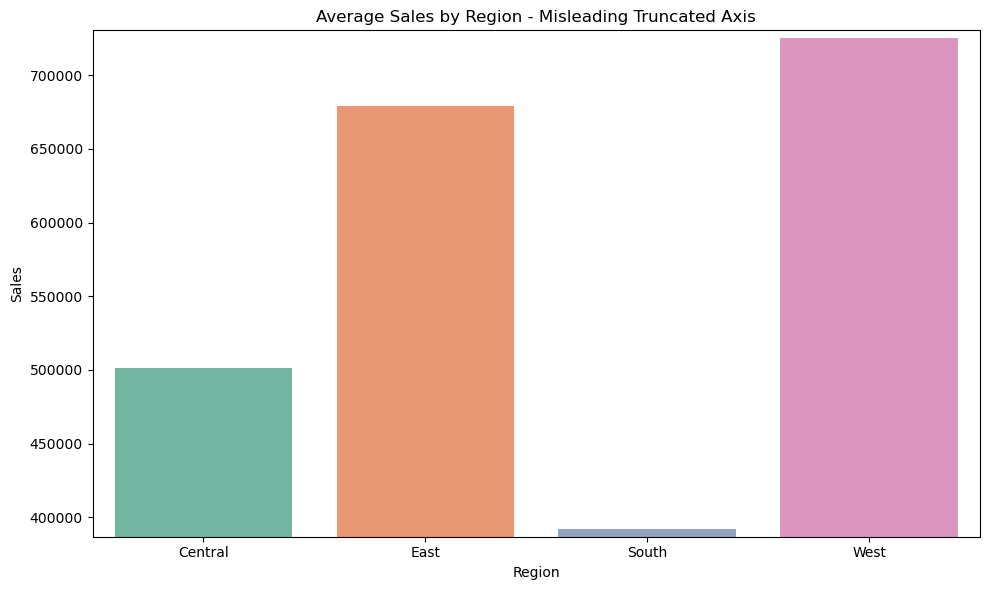

In [93]:
# 5. Using the region-sales and monthly-sales/monthly-profit data from earlier tasks,
# produce at least 3 of the following, each with a one-line caption naming the exact
# distortion mechanism:

# truncated y axis
plt.figure(figsize=(10, 6))

sns.barplot(
    data=salesByRegion,
    x='Region',
    y='Sales',
    hue='Region',
    palette='Set2',
    legend=False
)

# TRUNCATED Y-AXIS
plt.ylim(
    salesByRegion['Sales'].min() - 5000,
    salesByRegion['Sales'].max() + 5000
)

plt.title('Average Sales by Region - Misleading Truncated Axis')
plt.xlabel('Region')
plt.ylabel('Sales')

plt.tight_layout()
plt.show()

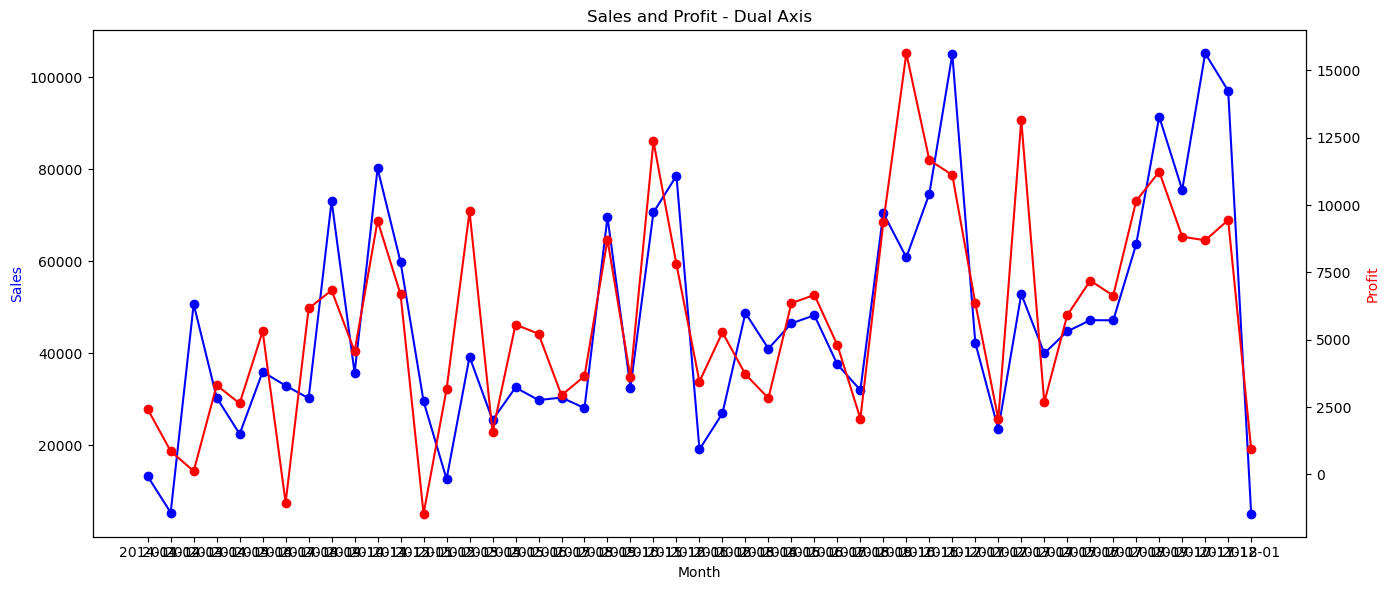

In [97]:
# dual excess chart
fig, ax1 = plt.subplots(figsize=(14, 6))

# Sales
ax1.plot(
    salesByMonth['Ship Date'],
    salesByMonth['Sales'],
    color='blue',
    marker='o',
    label='Sales'
)

ax1.set_xlabel('Month')
ax1.set_ylabel('Sales', color='blue')

# Profit on second axis
ax2 = ax1.twinx()

ax2.plot(
    profitByMonth['Ship Date'],
    profitByMonth['Profit'],
    color='red',
    marker='o',
    label='Profit'
)

ax2.set_ylabel('Profit', color='red')

plt.title('Sales and Profit - Dual Axis')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

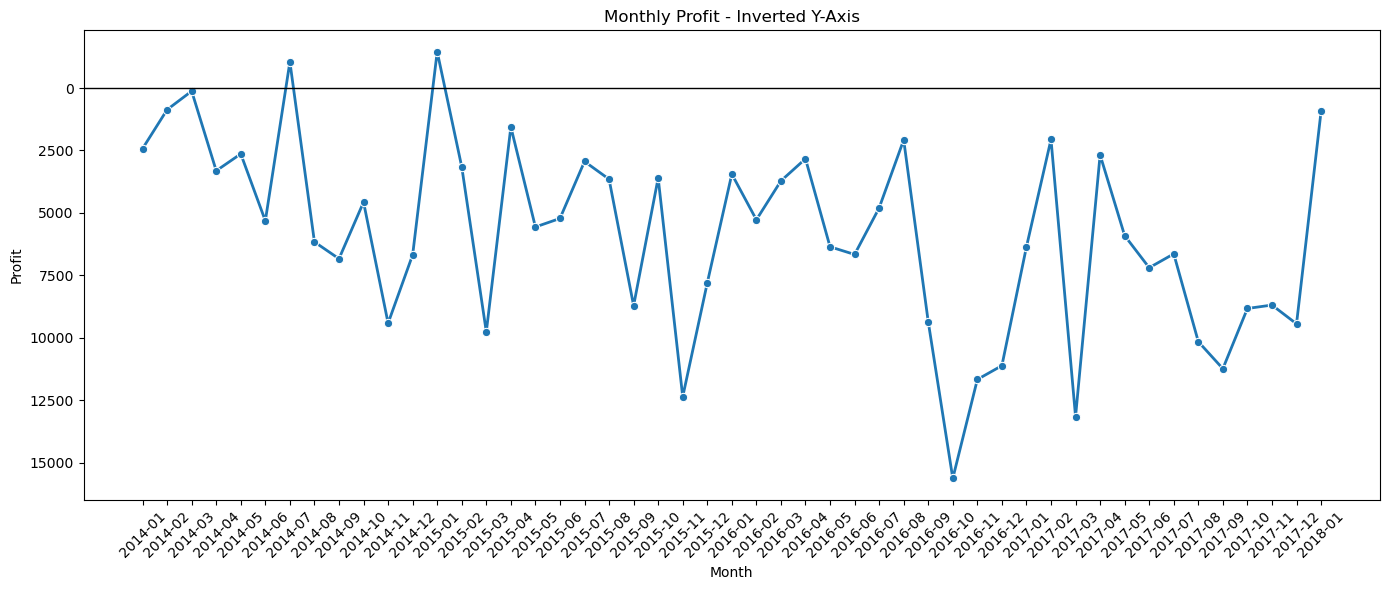

In [95]:
# inverted y axis
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=profitByMonth,
    x='Ship Date',
    y='Profit',
    marker='o',
    linewidth=2
)

# INVERTED Y-AXIS
plt.gca().invert_yaxis()

plt.axhline(0, color='black', linewidth=1)

plt.title('Monthly Profit - Inverted Y-Axis')
plt.xlabel('Month')
plt.ylabel('Profit')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

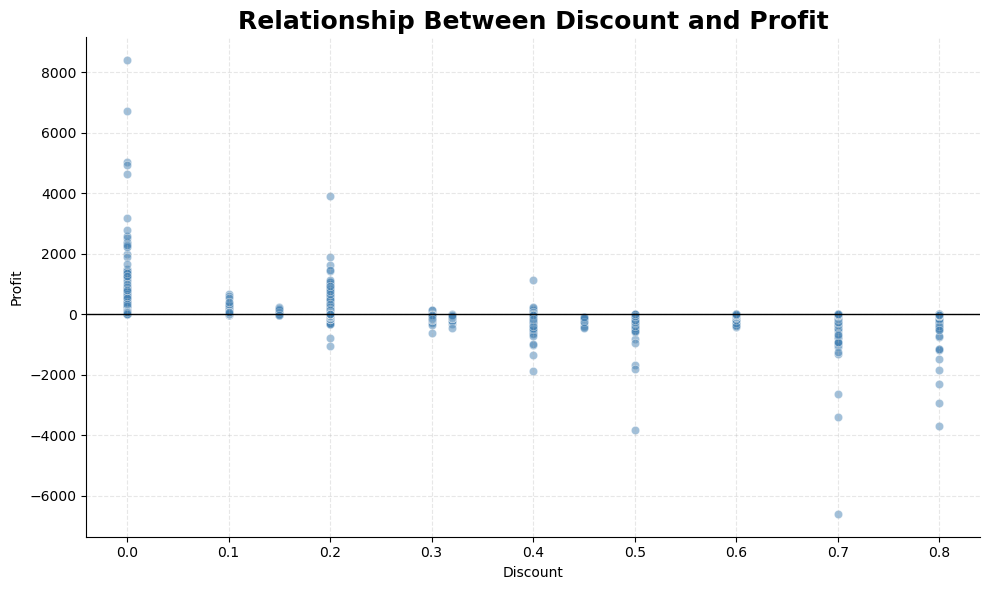

In [98]:
# 6. Pick one real analytical question about the dataset (e.g., "Is discounting hurting
# profit?" using the raw discount/profit columns — no summarizing required). Submit:
# • The honest, appropriately-chosen chart answering it.
# • A deliberately misleading version of the same question.
# • A short written justification covering chart type choice, color choice, and an
# accessibility check.

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Discount',
    y='Profit',
    color='steelblue',
    alpha=0.5
)

plt.axhline(0, color='black', linewidth=1)

plt.title('Relationship Between Discount and Profit',
          fontsize=18, fontweight='bold')
plt.xlabel('Discount')
plt.ylabel('Profit')

plt.grid(True, linestyle='--', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()


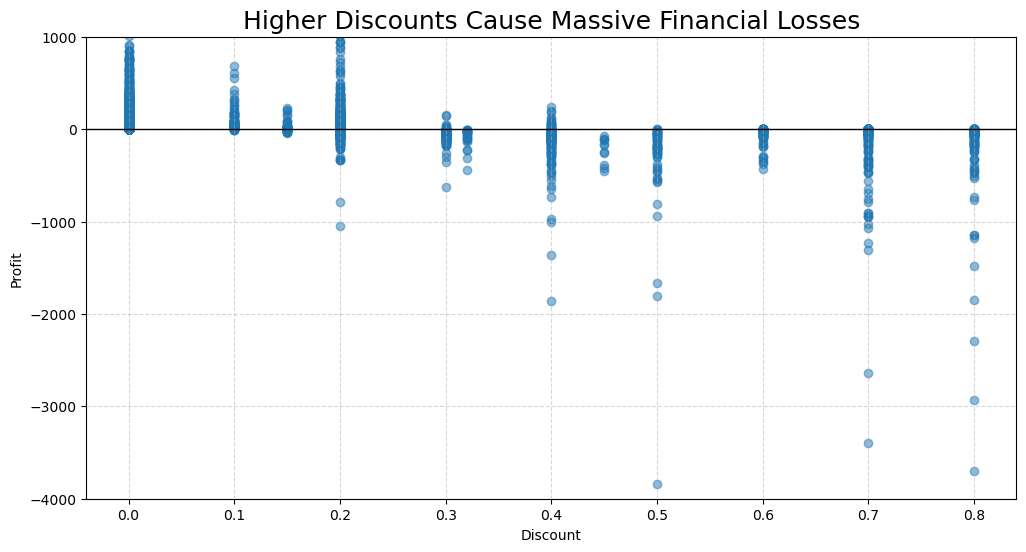

In [101]:
# misleading chart
plt.figure(figsize=(12, 6))
plt.scatter(df['Discount'], df['Profit'], alpha=0.5)
plt.axhline(y=0, color='black', linewidth=1)
# Misleading zoomed axis - exaggerates the losses
plt.ylim(-4000, 1000)
plt.title('Higher Discounts Cause Massive Financial Losses', fontsize=18)
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
# because scatterplot is used for numeric value comparisons. Since we are comparing the discount and the profit sooo thats why its better